In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
plt.style.use('ggplot')

In [4]:
df = pd.read_csv('amazon.csv')

In [7]:
df.columns

Index(['order_id', 'order_date', 'product_id', 'product_category', 'price',
       'discount_percent', 'quantity_sold', 'customer_region',
       'payment_method', 'rating', 'review_count', 'discounted_price',
       'total_revenue'],
      dtype='object')

In [9]:
df.isnull().sum()

order_id            0
order_date          0
product_id          0
product_category    0
price               0
discount_percent    0
quantity_sold       0
customer_region     0
payment_method      0
rating              0
review_count        0
discounted_price    0
total_revenue       0
dtype: int64

In [11]:
df.head()

,order_id,order_date,product_id,product_category,price,discount_percent,quantity_sold,customer_region,payment_method,rating,review_count,discounted_price,total_revenue
0,1,2022-04-13,2637,Books,128.75,10,4,North America,UPI,3.5,443,115.88,463.52
1,2,2023-03-12,2300,Fashion,302.60,20,5,Asia,Credit Card,3.7,475,242.08,1210.40
2,3,2022-09-28,3670,Sports,495.80,20,2,Europe,UPI,4.4,183,396.64,793.28
3,4,2022-04-17,2522,Books,371.95,15,4,Middle East,UPI,5.0,212,316.16,1264.64
4,5,2022-03-13,1717,Beauty,201.68,0,4,Middle East,UPI,4.6,308,201.68,806.72


In [13]:
df.count()

order_id            50000
order_date          50000
product_id          50000
product_category    50000
price               50000
discount_percent    50000
quantity_sold       50000
customer_region     50000
payment_method      50000
rating              50000
review_count        50000
discounted_price    50000
total_revenue       50000
dtype: int64

In [15]:
df.shape

(50000, 13)

In [17]:
df.describe()

,order_id,product_id,price,discount_percent,quantity_sold,rating,review_count,discounted_price,total_revenue
count,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,25000.500000,2986.848740,252.507260,13.340700,2.999400,2.996316,249.329280,218.886566,657.331475
std,14433.901067,1156.374535,143.025544,9.850694,1.415401,1.154295,144.251981,127.317681,526.223968
min,1.000000,1000.000000,5.010000,0.000000,1.000000,1.000000,0.000000,3.530000,3.840000
25%,12500.750000,1983.000000,127.840000,5.000000,2.000000,2.000000,125.000000,109.680000,240.320000
50%,25000.500000,2983.000000,252.970000,10.000000,3.000000,3.000000,250.000000,215.805000,505.410000
75%,37500.250000,3989.000000,376.335000,20.000000,4.000000,4.000000,374.000000,322.702500,968.970000
max,50000.000000,4999.000000,499.990000,30.000000,5.000000,5.000000,499.000000,499.910000,2499.550000


Text(0, 0.5, 'Number of Transactions')

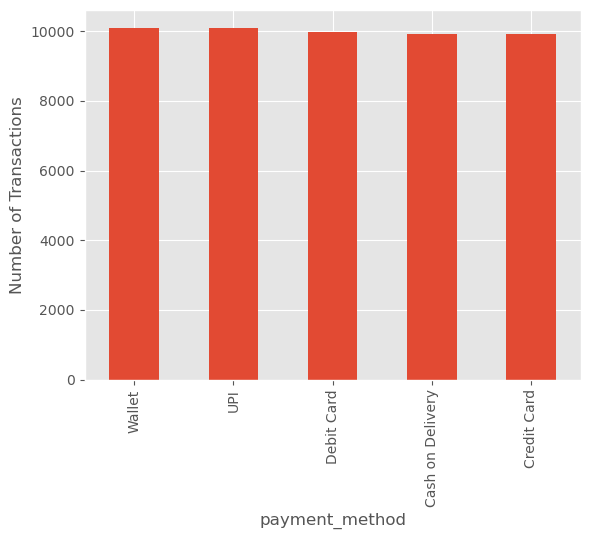

In [19]:
ax = df['payment_method'].value_counts().plot(kind = 'bar')
ax.set_ylabel('Number of Transactions')

**What it tells you**: Which payment options your customers prefer and trust the most.

**Business Insight**: "The data reveals that [Payment Method, e.g., Credit Card/UPI] is the overwhelmingly preferred payment option, used in [X%] of all transactions. In contrast, [Lowest Method] is rarely utilized."

**Actionable Recommendation**: "Ensure the checkout pipeline for [Top Payment Method] remains highly optimized and bug-free to prevent cart abandonment. Consider running a promotional campaign (e.g., 5% cashback) to encourage the use of lesser-used, lower-fee payment methods."

In [20]:
df.columns

Index(['order_id', 'order_date', 'product_id', 'product_category', 'price',
       'discount_percent', 'quantity_sold', 'customer_region',
       'payment_method', 'rating', 'review_count', 'discounted_price',
       'total_revenue'],
      dtype='object')

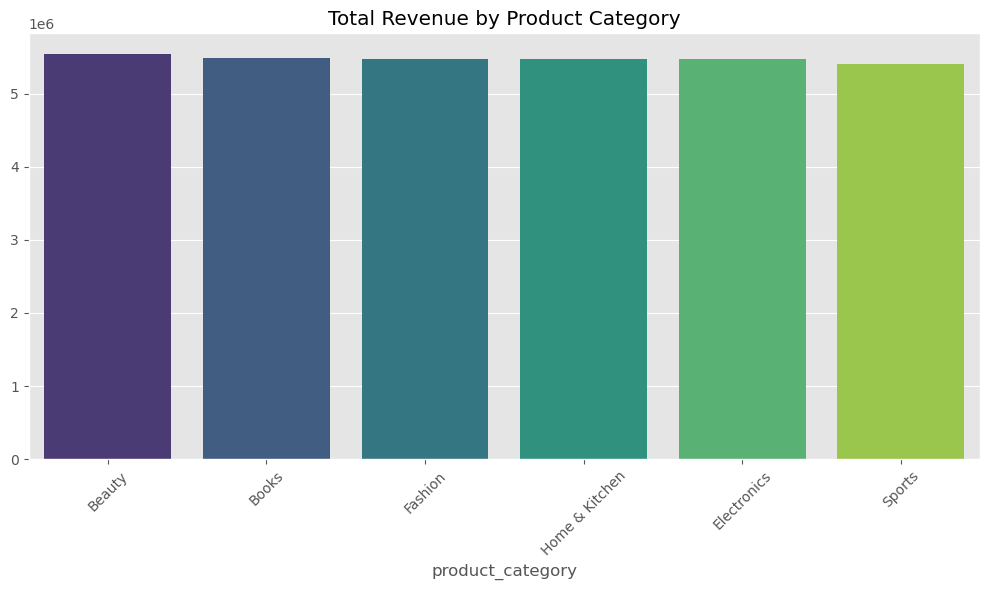

In [21]:
# Total Revenue by Product Category
category_revenue = df.groupby('product_category')['total_revenue'].sum().sort_values(ascending=False)
# plt.figure(figsize=(10, 6))
# sns.barplot(x=category_revenue.index, y=category_revenue.values, palette='viridis')
# plt.title('Total Revenue by Product Category')
# plt.xticks(rotation=45)
# plt.savefig('revenue_by_category.png')

# Updated barplot to resolve the FutureWarning
plt.figure(figsize=(10, 6))
sns.barplot(
    x=category_revenue.index, 
    y=category_revenue.values, 
    hue=category_revenue.index,  # Assign x to hue
    palette='viridis', 
    legend=False                # Hide the legend
)
plt.title('Total Revenue by Product Category')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('revenue_by_category.png')

**What it tells you**: Which product lines are the actual cash cows for the business.

**Business Insight**: "While some categories may have high sales volume, [Top Category, e.g., Fashion] is the primary revenue driver, generating [$X] in total sales. Conversely, [Lowest Category] contributes only a fraction to the bottom line."

**Actionable Recommendation**: "Allocate a larger portion of the marketing budget to [Top Category] to maximize ROI. For [Lowest Category], investigate whether the low revenue is due to low demand, poor visibility, or pricing issues."

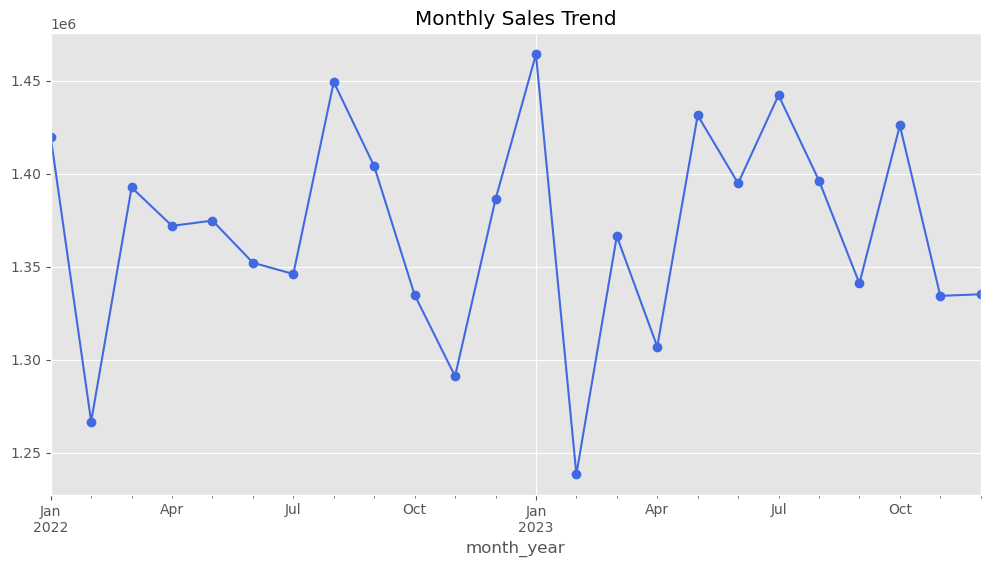

In [22]:
# Monthly Sales Trend
df['order_date'] = pd.to_datetime(df['order_date'])
df['month_year'] = df['order_date'].dt.to_period('M')
monthly_sales = df.groupby('month_year')['total_revenue'].sum()
plt.figure(figsize=(12, 6))
monthly_sales.plot(kind='line', marker='o', color='royalblue')
plt.title('Monthly Sales Trend')
plt.grid(True)
plt.savefig('monthly_sales_trend.png')

**What it tells you**: Seasonality, growth trajectories, and the impact of holidays or promotional events.

**Business Insight**: "Sales exhibit strong seasonality, with a distinct revenue spike in [Peak Month, e.g., November], likely driven by [cause, e.g., Black Friday/Holiday shopping]. We also observe a noticeable dip during [Lowest Month], representing the slowest sales period of the year."

**Actionable Recommendation**: "Inventory and supply chain logistics must be scaled up aggressively in the weeks leading up to [Peak Month]. To combat the slump in [Lowest Month], implement off-season promotional events or targeted email campaigns to stimulate demand."

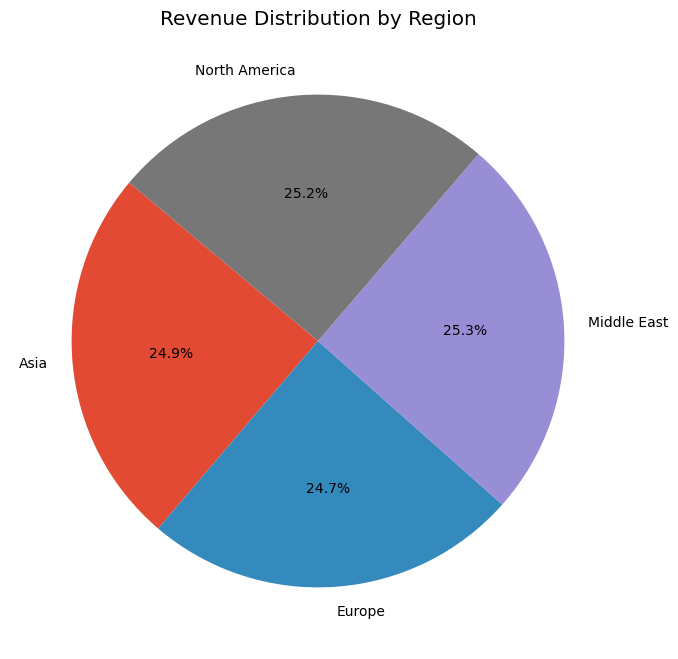

In [25]:
# Revenue Distribution by Region
region_revenue = df.groupby('customer_region')['total_revenue'].sum()
plt.figure(figsize=(8, 8))
plt.pie(region_revenue, labels=region_revenue.index, autopct='%1.1f%%', startangle=140)
plt.title('Revenue Distribution by Region')
plt.savefig('revenue_by_region.png')

**What it tells you**: The geographic footprint of your sales and where your market penetration is strongest.

**Business Insight**: "[Top Region, e.g., North America] dominates the market, accounting for [X%] of total global revenue. Meanwhile, emerging regions like [Lowest Region, e.g., Middle East] currently represent an untapped market with only [Y%] of the revenue share."

**Actionable Recommendation**: "Double down on customer retention strategies in [Top Region] to protect market share. To drive global growth, launch localized advertising and shipping discounts in [Lowest Region] to capture new market segments."

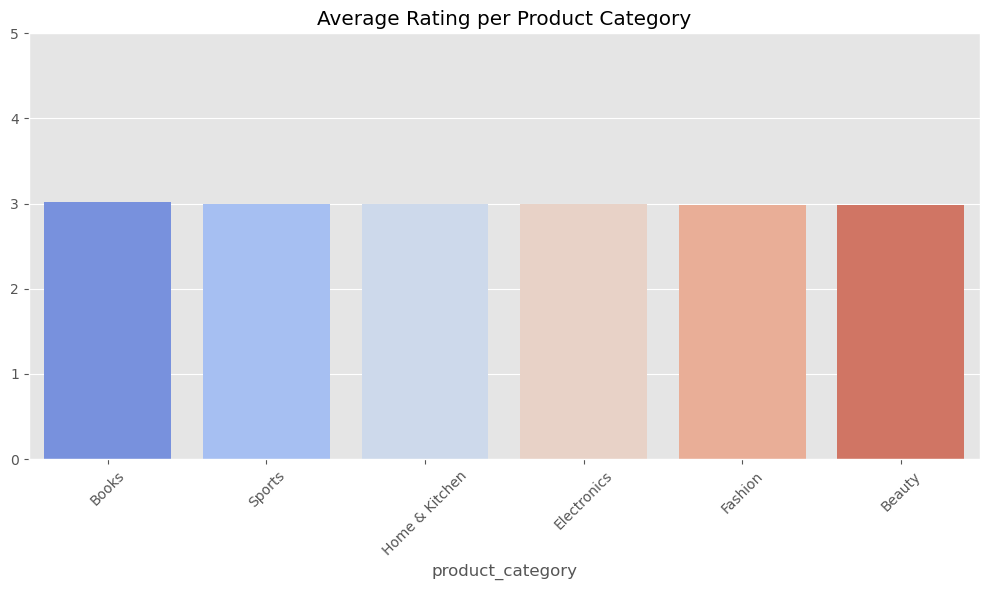

In [26]:
# Average Rating per Category
avg_rating = df.groupby('product_category')['rating'].mean().sort_values(ascending=False)
plt.figure(figsize=(10, 6))
sns.barplot(
    x=avg_rating.index, 
    y=avg_rating.values, 
    hue=avg_rating.index,        # Assign x to hue
    palette='coolwarm', 
    legend=False                # Hide the legend
)
plt.title('Average Rating per Product Category')
plt.ylim(0, 5)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('avg_rating_by_category.png')

**What it tells you**: Customer satisfaction and potential quality control issues.

**Business Insight**: "Customer satisfaction peaks in the [Top Rated Category, e.g., Books] category with an impressive average rating of [X.X]/5.0. However, the [Lowest Rated Category, e.g., Beauty] category struggles with an average rating of just [Y.Y], indicating significant customer dissatisfaction."

**Actionable Recommendation: "Flag the [Lowest Rated Category] for immediate quality assurance review. High return rates and negative reviews here could be damaging the brand's overall reputation. Consider bundling high-rated products with average-rated products to boost overall perception."